In [1]:
import sys
import pickle
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pairs.data import download_prices
from src.pairs.backtest import backtest_pair

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
prices = download_prices()
with open(project_root / "data" / "processed" / "kalman_results.pkl", "rb") as f:
    kalman_results = pickle.load(f)
print(f"Loaded Kalman results for {len(kalman_results)} pairs")

Loaded Kalman results for 8 pairs


In [3]:
results = {}
summaries = []

for (y, x), kr in kalman_results.items():
    print(f"Backtesting {y}/{x}...", end=" ")
    bt = backtest_pair(
        kalman_result=kr,
        prices=prices,
        entry_sigma=2.0,
        cost_bps_per_leg=10.0,
        burn_in_days=252,
    )
    results[(y, x)] = bt
    s = bt.summary()
    summaries.append(s)
    print(f"n_trades={s['n_trades']}, "
          f"net_pnl={s['total_net_pnl']:.4f}, "
          f"sharpe={s['sharpe_daily']:.2f}")

summary_df = pd.DataFrame(summaries).sort_values("sharpe_daily", ascending=False)
summary_df

Backtesting GS/WFC... n_trades=49, net_pnl=-0.4770, sharpe=-1.59
Backtesting BA/GE... n_trades=49, net_pnl=0.0174, sharpe=0.03
Backtesting BA/CAT... n_trades=51, net_pnl=-0.4467, sharpe=-0.87
Backtesting COST/PG... n_trades=52, net_pnl=-0.2591, sharpe=-0.82
Backtesting C/JPM... n_trades=46, net_pnl=-0.2551, sharpe=-0.91
Backtesting AVGO/NVDA... n_trades=49, net_pnl=-0.2999, sharpe=-0.53
Backtesting KO/PG... n_trades=49, net_pnl=-0.2111, sharpe=-1.32
Backtesting CVX/SLB... n_trades=45, net_pnl=-0.1751, sharpe=-0.52


,pair,n_trades,win_rate,total_gross_pnl,total_costs,total_net_pnl,avg_trade_net,sharpe_daily,max_drawdown
1,BA/GE,49,0.632653,0.213358,0.196,0.017358,0.000354,0.029119,-0.269598
7,CVX/SLB,45,0.511111,0.004939,0.180,-0.175061,-0.003890,-0.524891,-0.212764
5,AVGO/NVDA,49,0.571429,-0.103892,0.196,-0.299892,-0.006120,-0.530029,-0.379034
3,COST/PG,52,0.461538,-0.051139,0.208,-0.259139,-0.004983,-0.822011,-0.277187
2,BA/CAT,51,0.490196,-0.242701,0.204,-0.446701,-0.008759,-0.871309,-0.508288
4,C/JPM,46,0.543478,-0.071108,0.184,-0.255108,-0.005546,-0.906465,-0.370645
6,KO/PG,49,0.306122,-0.015075,0.196,-0.211075,-0.004308,-1.321405,-0.233246
0,GS/WFC,49,0.367347,-0.281038,0.196,-0.477038,-0.009735,-1.593687,-0.520742


In [4]:
# Daily P&L per pair.
daily_pnls = pd.DataFrame({
    bt.pair: bt.daily_pnl
    for bt in results.values()
    if bt.daily_pnl is not None
})

# Portfolio = equal-weighted average of pair P&Ls.
portfolio_daily = daily_pnls.mean(axis=1)
portfolio_cum = portfolio_daily.cumsum()

# Stats.
n_trading_days = (portfolio_daily != 0).sum()
sharpe = (portfolio_daily.mean() / portfolio_daily.std()) * np.sqrt(252)
total_pnl = portfolio_cum.iloc[-1]

# Max drawdown.
running_max = portfolio_cum.cummax()
drawdown = portfolio_cum - running_max
max_dd = drawdown.min()

print("=== Equal-weighted portfolio (all candidate pairs) ===")
print(f"Annualized Sharpe:    {sharpe:.3f}")
print(f"Total cumulative PnL: {total_pnl:.4f}")
print(f"Max drawdown:         {max_dd:.4f}")
print(f"Win rate (daily):     {(portfolio_daily > 0).mean():.2%}")

=== Equal-weighted portfolio (all candidate pairs) ===
Annualized Sharpe:    -1.688
Total cumulative PnL: -0.2633
Max drawdown:         -0.2818
Win rate (daily):     15.58%


In [5]:
for (y, x), kr in kalman_results.items():
    s = kr.spread
    sig = kr.spread_std
    threshold = 2.0 * sig

    # How many days does the spread exceed the threshold?
    days_above = (s.abs() > threshold).sum()
    # Max absolute spread relative to threshold.
    max_abs = s.abs().max()
    # The ratio: how big does the spread get, in sigma units?
    max_sigma = max_abs / sig if sig > 0 else float("nan")

    print(f"{y}/{x}: "
          f"sigma={sig:.5f}, "
          f"threshold=±{threshold:.5f}, "
          f"max|spread|={max_abs:.5f} ({max_sigma:.2f}σ), "
          f"days_above_threshold={days_above}")

GS/WFC: sigma=0.15025, threshold=±0.30051, max|spread|=5.30886 (35.33σ), days_above_threshold=1
BA/GE: sigma=0.16559, threshold=±0.33117, max|spread|=5.80317 (35.05σ), days_above_threshold=1
BA/CAT: sigma=0.16611, threshold=±0.33221, max|spread|=5.80317 (34.94σ), days_above_threshold=1
COST/PG: sigma=0.15792, threshold=±0.31585, max|spread|=5.58255 (35.35σ), days_above_threshold=1
C/JPM: sigma=0.11827, threshold=±0.23654, max|spread|=4.16924 (35.25σ), days_above_threshold=1
AVGO/NVDA: sigma=0.09560, threshold=±0.19121, max|spread|=3.32062 (34.73σ), days_above_threshold=2
KO/PG: sigma=0.10807, threshold=±0.21613, max|spread|=3.81623 (35.31σ), days_above_threshold=1
CVX/SLB: sigma=0.12801, threshold=±0.25603, max|spread|=4.51286 (35.25σ), days_above_threshold=1


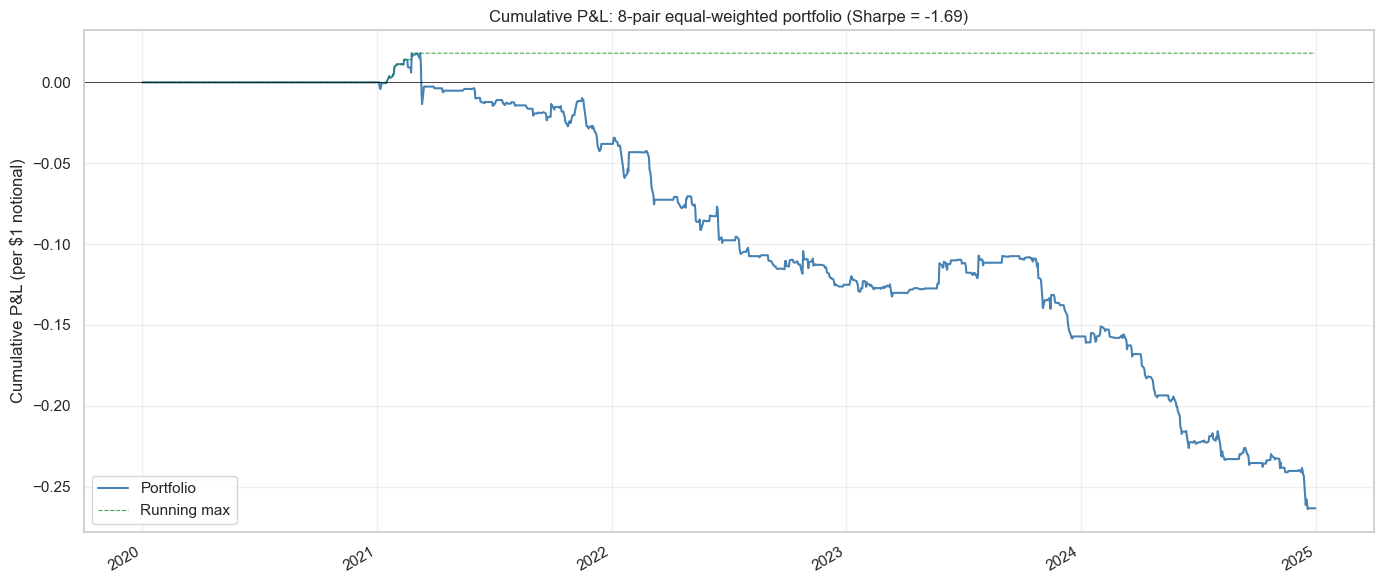

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
portfolio_cum.plot(ax=ax, color="steelblue", linewidth=1.5, label="Portfolio")
running_max.plot(ax=ax, color="green", linestyle="--", linewidth=0.8, alpha=0.7, label="Running max")
ax.set_title(f"Cumulative P&L: 8-pair equal-weighted portfolio (Sharpe = {sharpe:.2f})")
ax.set_ylabel("Cumulative P&L (per $1 notional)")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

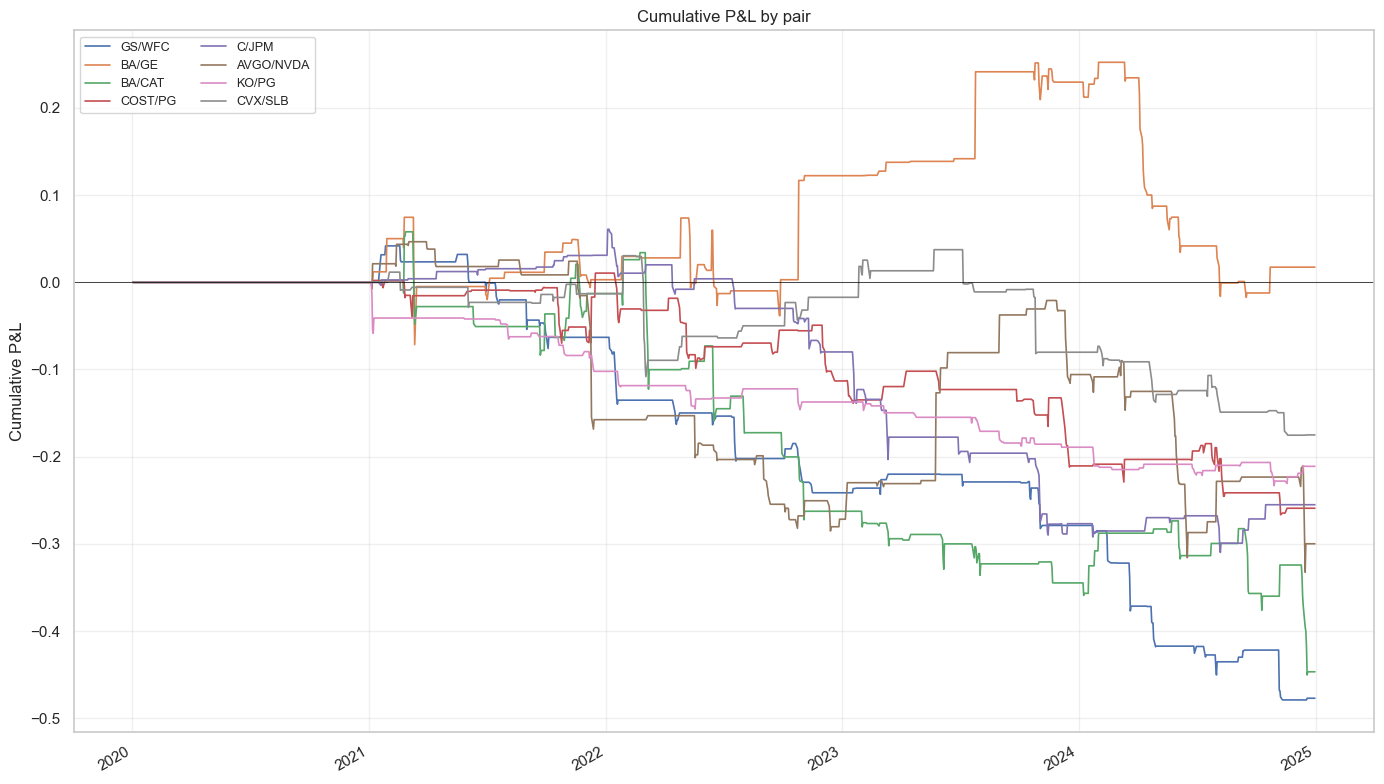

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))
for col in daily_pnls.columns:
    daily_pnls[col].cumsum().plot(ax=ax, label=col, linewidth=1.2)
ax.set_title("Cumulative P&L by pair")
ax.set_ylabel("Cumulative P&L")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(loc="best", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
thresholds = [1.5, 1.75, 2.0, 2.25, 2.5, 3.0]
threshold_results = []

for thr in thresholds:
    daily_per_pair = {}
    for (y, x), kr in kalman_results.items():
        bt = backtest_pair(kr, prices, entry_sigma=thr,
                           cost_bps_per_leg=10.0, burn_in_days=252)
        daily_per_pair[bt.pair] = bt.daily_pnl

    df = pd.DataFrame(daily_per_pair)
    port = df.mean(axis=1)
    sh = (port.mean() / port.std()) * np.sqrt(252) if port.std() > 0 else float("nan")
    n_total_trades = sum(
        backtest_pair(kr, prices, entry_sigma=thr,
                      cost_bps_per_leg=10.0, burn_in_days=252).summary()["n_trades"]
        for (_, _), kr in kalman_results.items()
    )
    threshold_results.append({
        "entry_sigma": thr,
        "n_trades_total": n_total_trades,
        "sharpe": sh,
        "total_pnl": float(port.cumsum().iloc[-1]),
    })

sens_df = pd.DataFrame(threshold_results)
sens_df

,entry_sigma,n_trades_total,sharpe,total_pnl
0,1.50,719,-1.560252,-0.309440
1,1.75,528,-1.678022,-0.298555
2,2.00,390,-1.688082,-0.263332
3,2.25,299,-1.762839,-0.233985
4,2.50,224,-1.525659,-0.183609
5,3.00,128,-1.024400,-0.092995


In [9]:
costs = [0.0, 2.5, 5.0, 10.0, 20.0]
cost_results = []

for c in costs:
    daily_per_pair = {}
    for (y, x), kr in kalman_results.items():
        bt = backtest_pair(kr, prices, entry_sigma=2.0,
                           cost_bps_per_leg=c, burn_in_days=252)
        daily_per_pair[bt.pair] = bt.daily_pnl
    df = pd.DataFrame(daily_per_pair)
    port = df.mean(axis=1)
    sh = (port.mean() / port.std()) * np.sqrt(252) if port.std() > 0 else float("nan")
    cost_results.append({"cost_bps_per_leg": c, "sharpe": sh,
                         "total_pnl": float(port.cumsum().iloc[-1])})

cost_df = pd.DataFrame(cost_results)
cost_df

,cost_bps_per_leg,sharpe,total_pnl
0,0.0,-0.412950,-0.068332
1,2.5,-0.719066,-0.117082
2,5.0,-1.034141,-0.165832
3,10.0,-1.688082,-0.263332
4,20.0,-3.060016,-0.458332


In [10]:
import pickle

with open(project_root / "data" / "processed" / "backtest_results.pkl", "wb") as f:
    pickle.dump(results, f)
summary_df.to_parquet(project_root / "data" / "processed" / "backtest_summary.parquet")
sens_df.to_parquet(project_root / "data" / "processed" / "threshold_sensitivity.parquet")
cost_df.to_parquet(project_root / "data" / "processed" / "cost_sensitivity.parquet")
print("Saved backtest artifacts.")

Saved backtest artifacts.
